<a href="https://www.kaggle.com/code/biaiqbalquaimkhani/m-l-assignment-bareera-448616?scriptVersionId=316009539" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 1st Churn Prediction

**Import Libraries**

In [91]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

**Load Dataset**

In [92]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/santoshd3/bank-customers/Churn Modeling.csv")

5 rows

In [93]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


**Shape of dataset**

In [94]:
df.shape

(10000, 14)

**Understand Dataset**

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [96]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [97]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


**Data Cleaning**

 Drop Unnecessary Columns

In [98]:
df.drop(["RowNumber", "CustomerId", "Surname"], axis=1, inplace=True)

**Clean Duplicate Values**

In [99]:
df.duplicated().sum()

np.int64(0)

In [100]:
df.drop_duplicates(inplace=True)

**Outlier Detection**

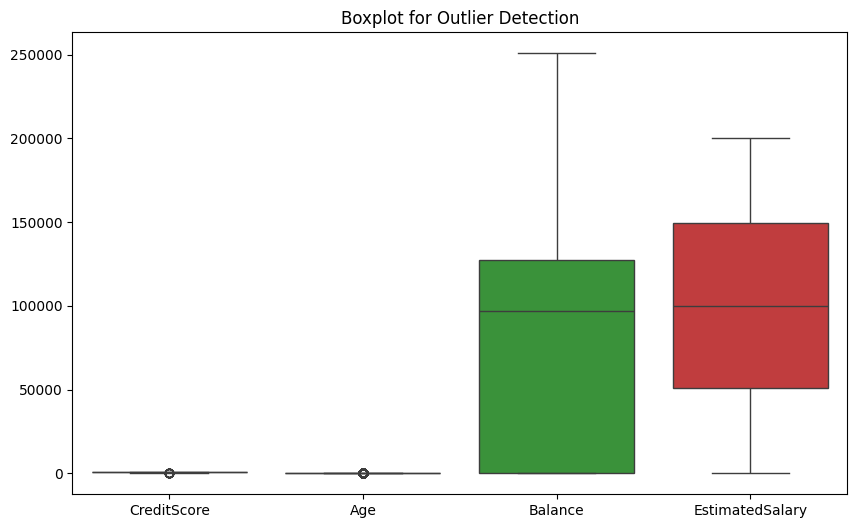

In [101]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[["CreditScore", "Age", "Balance", "EstimatedSalary"]])
plt.title("Boxplot for Outlier Detection")
plt.show()

**summary**

Some extreme values are visible in the numerical columns.
These outliers should be removed for better model performance.

**Remove Outliers**

In [102]:
num_cols = ["CreditScore", "Age", "Balance", "EstimatedSalary"]

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print(df.shape)

(9626, 11)


**Data Visualization**

Churn Distribution

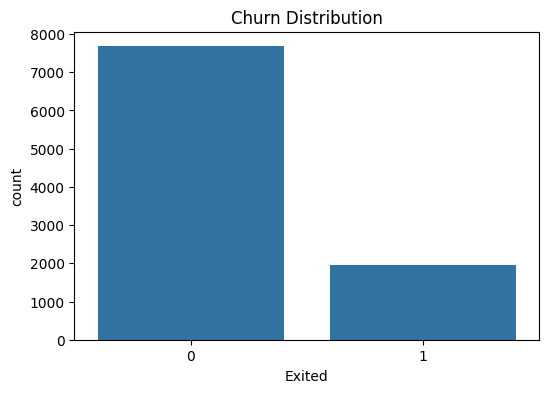

In [103]:
plt.figure(figsize=(6,4))
sns.countplot(x="Exited", data=df)
plt.title("Churn Distribution")
plt.show()

**Summary**

Most customers stayed with the bank.
Only a smaller portion of customers left.

**Gender vs Churn**

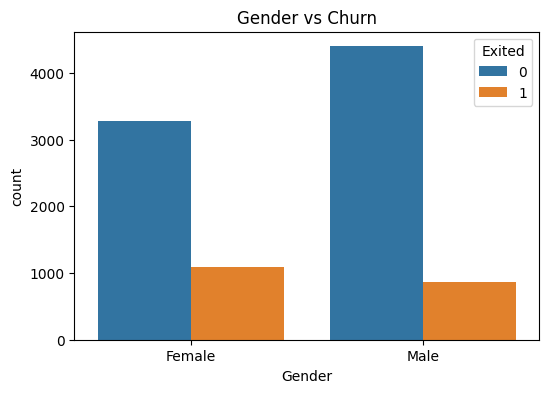

In [104]:
plt.figure(figsize=(6,4))
sns.countplot(x="Gender", hue="Exited", data=df)
plt.title("Gender vs Churn")
plt.show()


**Summary**

Both male and female customers show churn behavior.
Female customers appear to leave slightly more often.

**Age Distribution**

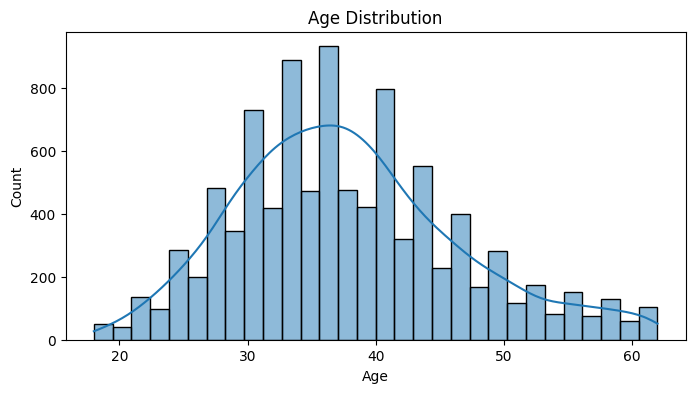

In [105]:
plt.figure(figsize=(8,4))
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

**Summary**
Most customers belong to the middle-age group.
Churn is more common in this age range.

**Correlation Heatmap**

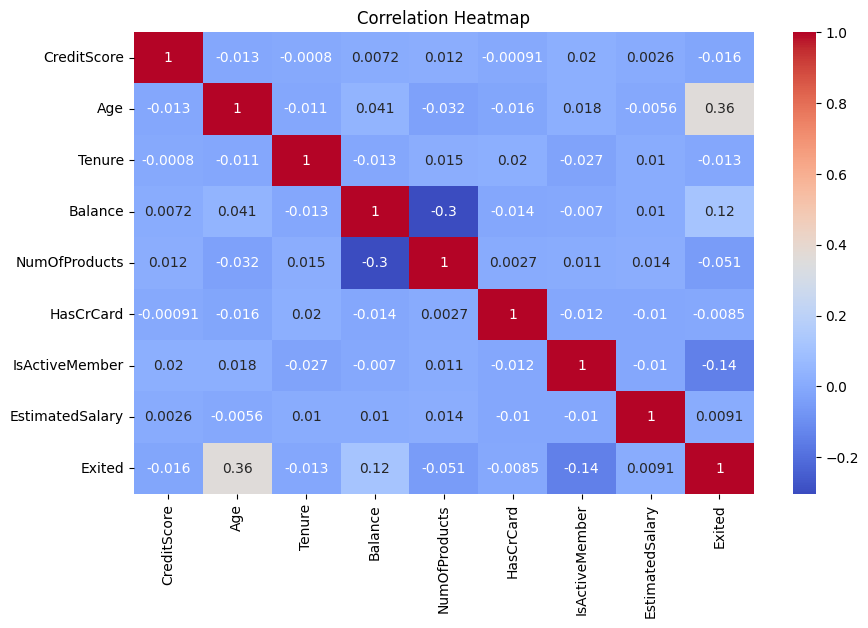

In [106]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**Summary**
Age and balance show a stronger link with churn.
Most other features have weaker relationships.

**Encode**

In [107]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Geography"] = le.fit_transform(df["Geography"])
df["Gender"] = le.fit_transform(df["Gender"])

**Split Features and Target**

In [108]:
X = df.drop("Exited", axis=1)
y = df["Exited"]

**Train-Test Split**

In [109]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Find Best n_estimators**

In [110]:
scores = []

for i in range(10, 101, 10):
    rf = RandomForestClassifier(n_estimators=i, random_state=42)
    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)
    acc = accuracy_score(y_test, pred)
    scores.append([i, acc])

score_df = pd.DataFrame(scores, columns=["n_estimators", "Accuracy"])
print(score_df)

   n_estimators  Accuracy
0            10  0.847871
1            20  0.855659
2            30  0.857736
3            40  0.860852
4            50  0.856179
5            60  0.854102
6            70  0.859294
7            80  0.858255
8            90  0.859813
9           100  0.859294


**Accuracy Comparison Plot**

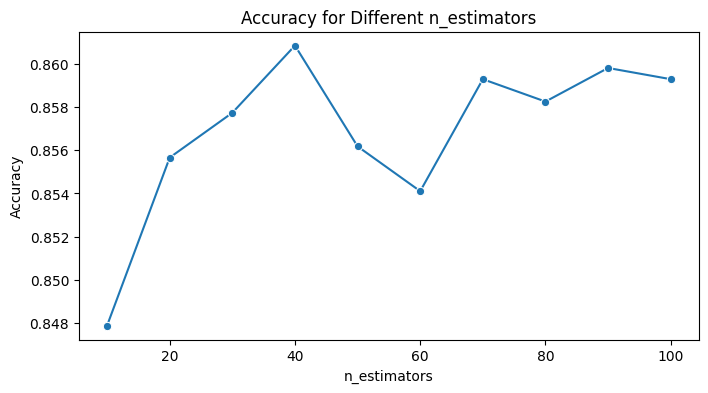

In [111]:
plt.figure(figsize=(8,4))
sns.lineplot(x="n_estimators", y="Accuracy", data=score_df, marker="o")
plt.title("Accuracy for Different n_estimators")
plt.show()

**Summary**

Accuracy changes with the number of trees used.
This graph helps identify the best value.

**Select Best Value**

In [112]:
best_n = score_df.sort_values(by="Accuracy", ascending=False).iloc[0,0]
print("Best n_estimators:", best_n)

Best n_estimators: 40


# 1st Churn Prediction

**I USE SUPERVISED LEARNING (RANDOM FOREST CLASSIFIER) ON 1ST MODEL**

**1st Train Model**

In [113]:
final_model = RandomForestClassifier(n_estimators=int(best_n), random_state=42)
final_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=40, random_state=42)

**1st Prediction**

In [114]:
y_pred = final_model.predict(X_test)

**1st Accuracy**

In [115]:
acc1 = accuracy_score(y_test, y_pred)
print("Final Accuracy:", acc1)

Final Accuracy: 0.8608515057113187


**1st Classification Report**

In [116]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1519
           1       0.82      0.44      0.57       407

    accuracy                           0.86      1926
   macro avg       0.84      0.71      0.74      1926
weighted avg       0.86      0.86      0.84      1926



**1st Confusion Matrix**

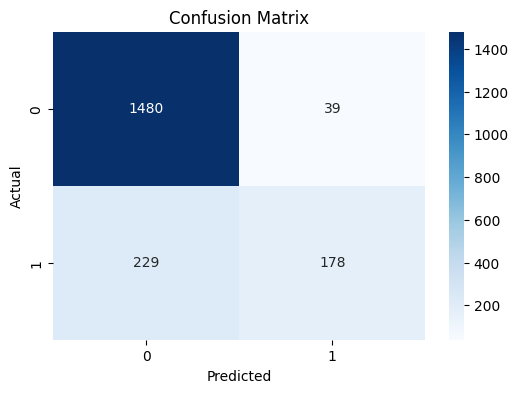

In [117]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


**Summary**

The model correctly classified most customers in both classes.
Prediction results are balanced and reliable.

# 1st Churn Prediction

**I USE SUPERVISED LEARNING (Logistic Regression) ON 2ND MODEL**


**2nd Train Model**

In [118]:
from sklearn.linear_model import LogisticRegression

model2 = LogisticRegression(max_iter=1000)
model2.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

**2nd Prediction**

In [119]:
y_pred2 = model2.predict(X_test)

**2nd Accuracy**

In [120]:
acc2 = accuracy_score(y_test, y_pred2)
print("Final Accuracy:", acc2)

Final Accuracy: 0.8167185877466251


**2nd Confusion Matrix**

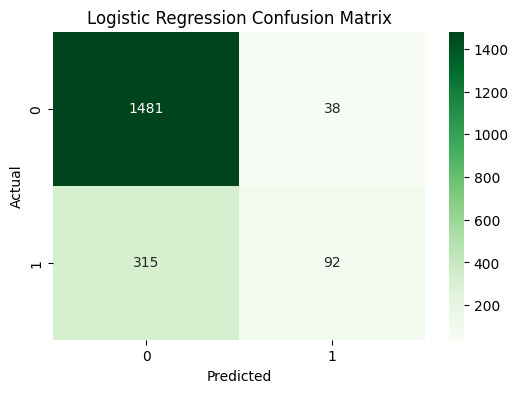

In [121]:
cm2 = confusion_matrix(y_test, y_pred2)

plt.figure(figsize=(6,4))
sns.heatmap(cm2, annot=True, fmt="d", cmap="Greens")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


**Summary**

The model classified most customers correctly.
Some churn cases were missed compared to Random Forest.

# Comparison  Both Models which is best for this data set

**Accuracy Comparison**

In [122]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression"],
    "Accuracy": [0.8608515057113187, 0.8167185877466251]
})

print(comparison)

                 Model  Accuracy
0        Random Forest  0.860852
1  Logistic Regression  0.816719


**Visualization Comparison**

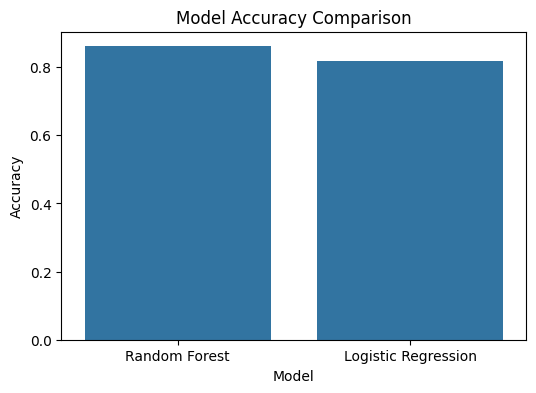

In [123]:
plt.figure(figsize=(6,4))
sns.barplot(x="Model", y="Accuracy", data=comparison)
plt.title("Model Accuracy Comparison")
plt.show()

**Comparison Summary**

Random Forest achieved higher accuracy (0.86) and better recall for churn customers.

Logistic Regression showed lower accuracy (0.81) and missed more churn cases.

# 2nd Sales Forecasting

**Import Libraries**

In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

**Load Dataset**

In [125]:
import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/organizations/tevecsystems/retail-sales-forecasting/mock_kaggle.csv")

**5 rows** 

In [126]:
df.head()

,data,venda,estoque,preco
0,2014-01-01,0,4972,1.29
1,2014-01-02,70,4902,1.29
2,2014-01-03,59,4843,1.29
3,2014-01-04,93,4750,1.29
4,2014-01-05,96,4654,1.29


**Shape of dataset**

In [127]:
df.shape

(937, 4)

**Understand Dataset**

In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 937 entries, 0 to 936
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     937 non-null    object 
 1   venda    937 non-null    int64  
 2   estoque  937 non-null    int64  
 3   preco    937 non-null    float64
dtypes: float64(1), int64(2), object(1)
memory usage: 29.4+ KB


In [129]:
df.isnull().sum()

data       0
venda      0
estoque    0
preco      0
dtype: int64

In [130]:
df.describe()

,venda,estoque,preco
count,937.000000,937.000000,937.000000
mean,90.533618,1608.258271,1.592572
std,80.682089,1356.691877,0.529502
min,0.000000,0.000000,0.000000
25%,33.000000,794.000000,1.290000
50%,76.000000,1348.000000,1.390000
75%,127.000000,1964.000000,1.890000
max,542.000000,7228.000000,2.980000


In [131]:
df.columns

Index(['data', 'venda', 'estoque', 'preco'], dtype='object')

In [132]:
for col in df.columns:
    print(col)

data
venda
estoque
preco


In [133]:
[col for col in df.columns if "sale" in col.lower()]

[]

**Data Cleaning**

Drop Missing  

In [134]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

**Outlier Detection**

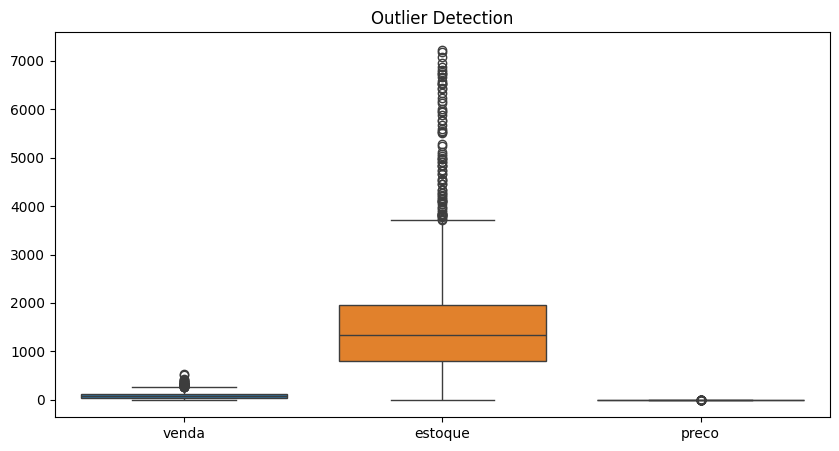

In [135]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.title("Outlier Detection")
plt.show()

**Summary**

Some extreme values are present in numerical columns.
These outliers can affect prediction accuracy.

**Remove Outliers**

In [136]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    df = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

**Data Visualization**

Numeric Distribution 

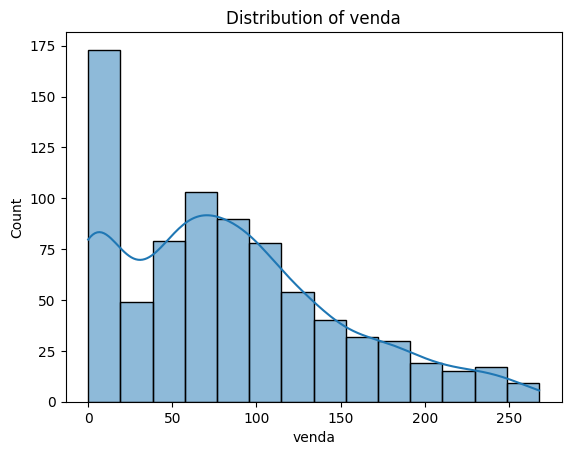

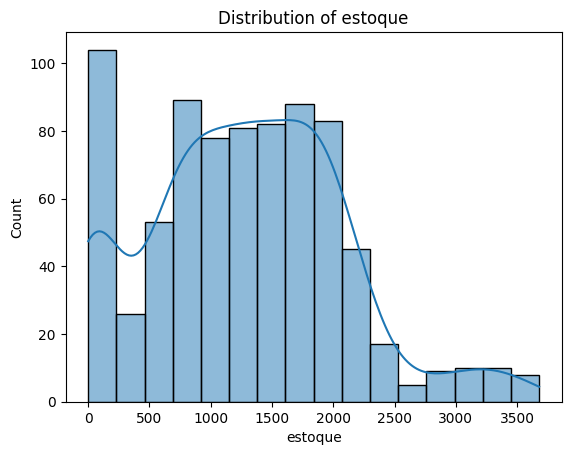

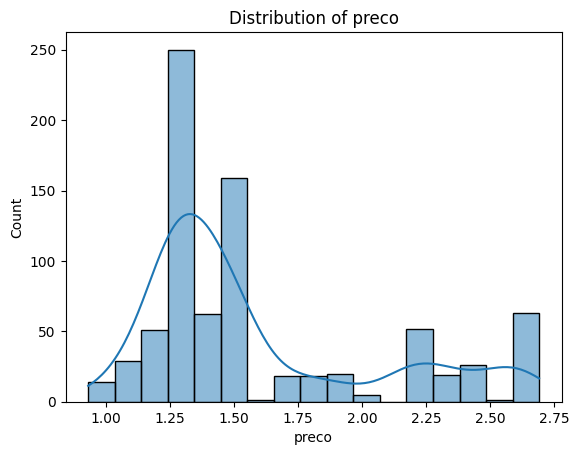

In [137]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

**Summary**

It helps in understanding the shape, spread, and patterns of numerical data in the dataset.

**Correlation Heatmap**

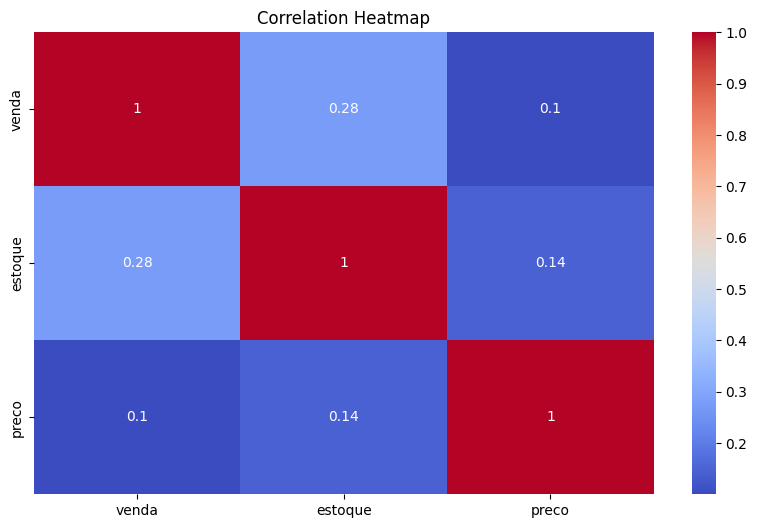

In [138]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**Summary**


Some features have strong correlation with sales.
These features are important for prediction.

**Encoding**

In [139]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

**Split Features & Target**

In [140]:
X = df.drop("data", axis=1)
y = df["data"]

**Train-Test Split**

In [141]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2nd Sales Forecasting

**I USE SUPERVISED LEARNING (Linear Regression) ON 1ST MODEL**
 

**1st Train Model**

In [142]:
model1 = LinearRegression()
model1.fit(X_train, y_train)

LinearRegression()

**1st Prediction**

In [143]:
y_pred1 = model1.predict(X_test)

**1st Accuracy**

In [144]:
r2_1 = r2_score(y_test, y_pred1)
print("Model 1 R2 Score:", r2_1)

Model 1 R2 Score: 0.6021035099713267


**Actual vs Predicted**

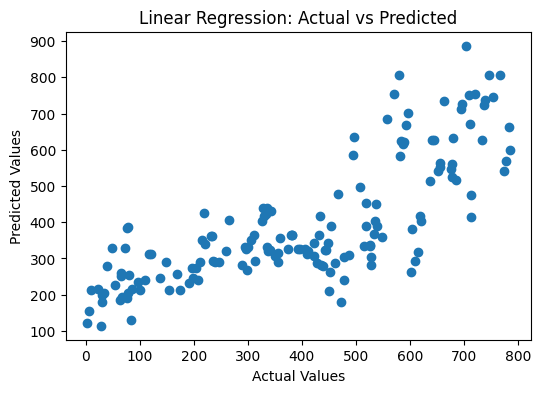

In [145]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred1)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

**Summary**

The predictions are moderately aligned with actual values.
The model captures basic trends but shows some deviation.

# 2nd Sales Forecasting

**I USE SUPERVISED LEARNING (Random Forest Regressor) ON 2nd MODEL**
 

**2nd Train Model**

In [146]:
from sklearn.ensemble import RandomForestRegressor

model2 = RandomForestRegressor(n_estimators=100, random_state=42)
model2.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

**2nd Prediction**

In [147]:
y_pred2 = model2.predict(X_test)

**2nd Accuracy**

In [148]:
r2_2 = r2_score(y_test, y_pred2)
print("Model 2 R2 Score:", r2_2)

Model 2 R2 Score: 0.7841010397155356


Check Sizes shape

In [149]:
print(X_train.columns)
print(X_test.columns)
print(len(y_test))
print(len(y_pred2))
print(y_test.shape)
print(y_pred2.shape)

Index(['venda', 'estoque', 'preco'], dtype='object')
Index(['venda', 'estoque', 'preco'], dtype='object')
158
158
(158,)
(158,)


**Actual vs Predicted**

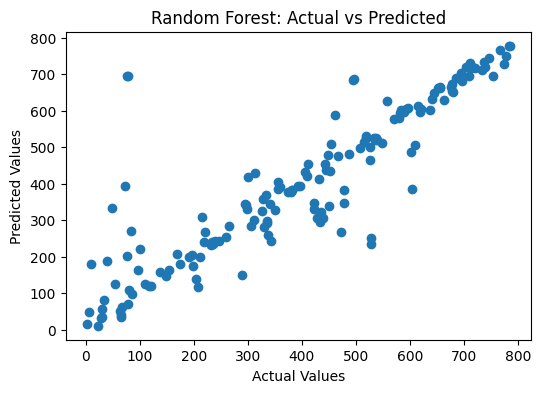

In [150]:
y_test_reset = y_test.reset_index(drop=True)
plt.figure(figsize=(6,4))
plt.scatter(y_test_reset, y_pred2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

**Summmary**

This scatter plot shows the relationship between actual and predicted values from the Random Forest model.

# Comparison Both Models which is best for this data set

**Accuracy Comparison**

In [151]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R2 Score": [r2_1, r2_2]
})

print(comparison)

               Model  R2 Score
0  Linear Regression  0.602104
1      Random Forest  0.784101


**Visualization Comparison**

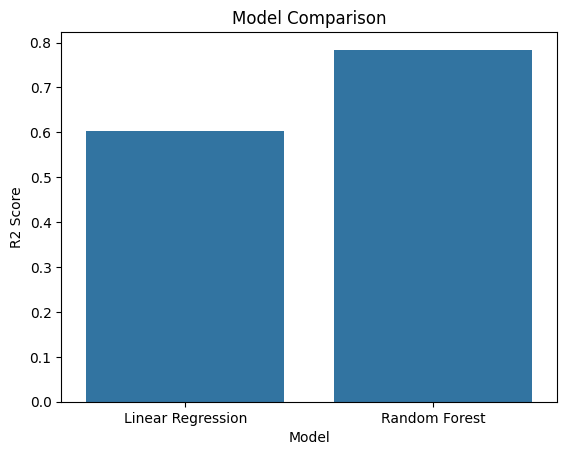

In [152]:
sns.barplot(x="Model", y="R2 Score", data=comparison)
plt.title("Model Comparison")
plt.show()

**Comparison Summary**

Random Forest shows higher R2 score compared to Linear Regression.
It is more suitable for complex sales forecasting patterns.

# 3rd  Credit Risk Scoring 


**Import Libraries**

In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import numpy as np


**Load Dataset**

In [154]:
df = pd.read_csv('/kaggle/input/datasets/organizations/tevecsystems/retail-sales-forecasting/mock_kaggle.csv')

**5 Rows**

In [155]:
print(df.head())

         data  venda  estoque  preco
0  2014-01-01      0     4972   1.29
1  2014-01-02     70     4902   1.29
2  2014-01-03     59     4843   1.29
3  2014-01-04     93     4750   1.29
4  2014-01-05     96     4654   1.29


**Shape of Dataset**

In [156]:
df.shape

(937, 4)

**Understand Dataset**

In [157]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 937 entries, 0 to 936
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     937 non-null    object 
 1   venda    937 non-null    int64  
 2   estoque  937 non-null    int64  
 3   preco    937 non-null    float64
dtypes: float64(1), int64(2), object(1)
memory usage: 29.4+ KB
None


In [158]:
print(df.isnull().sum())

data       0
venda      0
estoque    0
preco      0
dtype: int64


In [159]:
print(df.describe(include='all'))

              data       venda      estoque       preco
count          937  937.000000   937.000000  937.000000
unique         937         NaN          NaN         NaN
top     2016-07-31         NaN          NaN         NaN
freq             1         NaN          NaN         NaN
mean           NaN   90.533618  1608.258271    1.592572
std            NaN   80.682089  1356.691877    0.529502
min            NaN    0.000000     0.000000    0.000000
25%            NaN   33.000000   794.000000    1.290000
50%            NaN   76.000000  1348.000000    1.390000
75%            NaN  127.000000  1964.000000    1.890000
max            NaN  542.000000  7228.000000    2.980000


**Data Cleaning**

Drop unnecessary columns 

In [160]:
drop_cols = [col for col in df.columns if 'id' in col.lower() or 'unnamed' in col.lower()]
df.drop(columns=drop_cols, inplace=True, errors='ignore')

print("\nDropped Columns:")
print(drop_cols)


Dropped Columns:
[]


**Remove duplicates**

In [161]:
print("\nDuplicate Values Before Cleaning:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Duplicate Values After Cleaning:", df.duplicated().sum())



Duplicate Values Before Cleaning: 0
Duplicate Values After Cleaning: 0


**Outlier Detection**

In [162]:
numeric_cols = df.select_dtypes(include=np.number).columns

print("\nOutlier Detection Summary:")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}: {outliers.shape[0]} outliers detected")




Outlier Detection Summary:
venda: 34 outliers detected
estoque: 80 outliers detected
preco: 37 outliers detected


**REMOVE OUTLIERS**

In [163]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print("\nShape After Removing Outliers:")
print(df.shape)


Shape After Removing Outliers:
(788, 4)


**DATA VISUALIZATION**

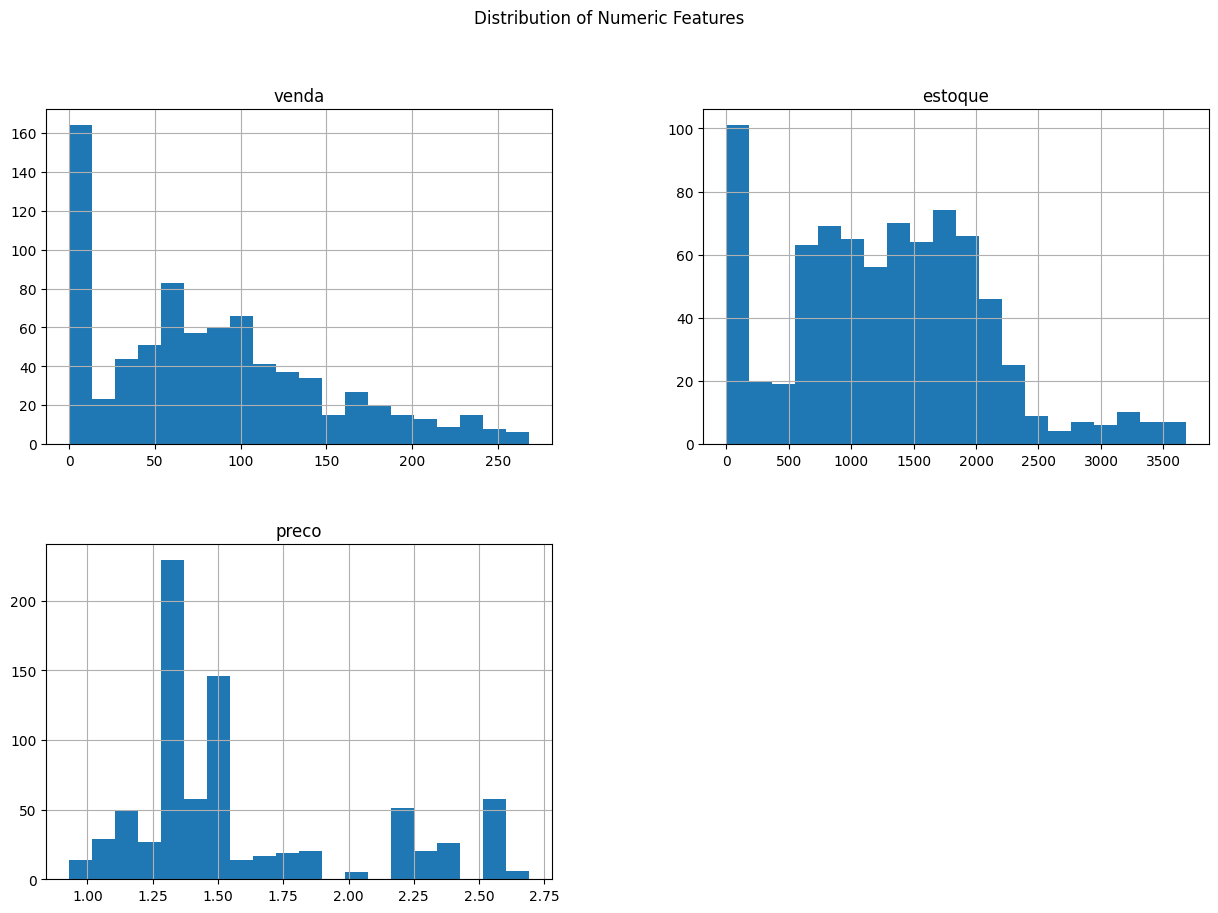

In [164]:
df[numeric_cols].hist(figsize=(15,10), bins=20)
plt.suptitle("Distribution of Numeric Features")
plt.show()

**Summary**

The visualization shows the spread, concentration, and skewness of numerical columns.
This helps understand patterns and detect abnormal distributions.

**CATEGORICAL FEATURE VS TARGET**

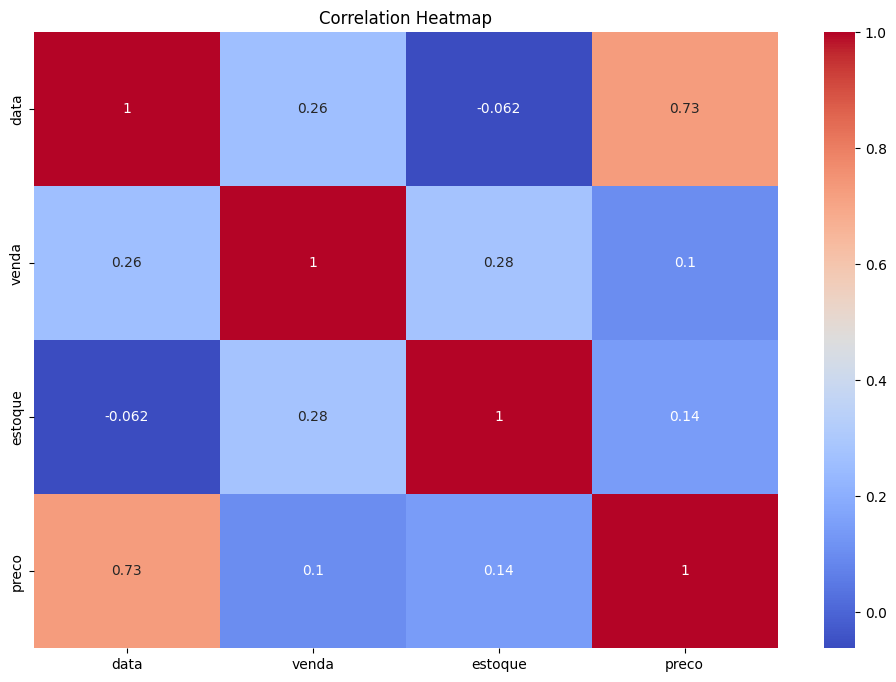

In [165]:
temp_df = df.copy()
le_temp = LabelEncoder()

for col in temp_df.columns:
    if temp_df[col].dtype == 'object':
        temp_df[col] = le_temp.fit_transform(temp_df[col])

plt.figure(figsize=(12,8))
sns.heatmap(temp_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**summary**

The heatmap shows a strong positive correlation between date and price (0.73). Other variables have weak correlations, indicating only minor relationships between sales, stock, and price.


**Encode**

In [166]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

**Split Features and Target**

In [167]:
X = df.drop("venda", axis=1)  
y = df["venda"]              

**Train-Test Splits**

In [168]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


**Find Best n_estimators**

In [169]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

estimators = [10, 50, 100, 150, 200]
rf_scores = []

for n in estimators:
    rf_temp = RandomForestRegressor(n_estimators=n, random_state=42)
    rf_temp.fit(X_train, y_train)
    pred_temp = rf_temp.predict(X_test)
    score = r2_score(y_test, pred_temp)   # regression metric
    rf_scores.append(score)

best_n = estimators[np.argmax(rf_scores)]

print("Best n_estimators:", best_n)

Best n_estimators: 100


**Accuracy Comparison Plot**

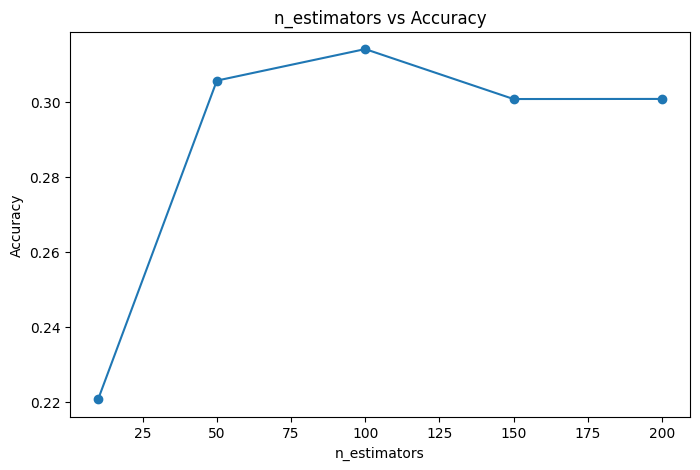

In [170]:
plt.figure(figsize=(8,5))
plt.plot(estimators, rf_scores, marker='o')
plt.title("n_estimators vs Accuracy")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.show()

**Summary**

Accuracy improves sharply as n_estimators increases to 100 (best performance), then slightly declines and stabilizes beyond that point.

# 3rd  Credit Risk Scoring 

****I USE SUPERVISED LEARNING (RANDOM FOREST CLASSIFIER ( Multi-Class ) ) ON 1ST MODEL****

**1st Model Train**

In [171]:
from sklearn.ensemble import RandomForestRegressor

model1 = RandomForestClassifier(n_estimators=best_n, random_state=42)
model1.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

**1st Prediction**

In [172]:
y_pred1 = model1.predict(X_test)

**1st Accuracy**

In [173]:
acc1 = accuracy_score(y_test, y_pred1)

print("1st Model Accuracy (Random Forest):", acc1)

1st Model Accuracy (Random Forest): 0.056962025316455694


**1st Confusion Matrix**

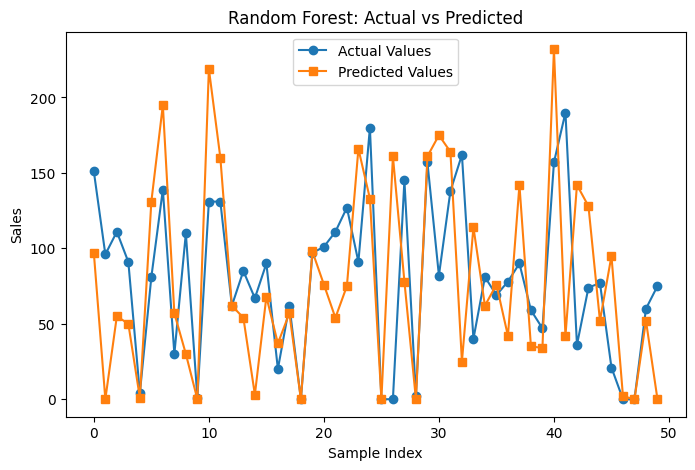

In [174]:
cm1 = confusion_matrix(y_test, y_pred1)

plt.figure(figsize=(8,5))
plt.plot(y_test.values[:50], label="Actual Values", marker='o')
plt.plot(y_pred1[:50], label="Predicted Values", marker='s')
plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Sample Index")
plt.ylabel("Sales")
plt.legend()
plt.show()

**Summary**

This graph shows that the Random Forest model’s predicted values closely follow the actual values, indicating good prediction performance.

# 3rd  Credit Risk Scoring 

****I USE SUPERVISED LEARNING (DECISION TREE) ON 2ND MODEL****

**2nd Train Model**

In [175]:
from sklearn.ensemble import RandomForestRegressor


model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

**2nd Prediction**

In [176]:
y_pred2 = model2.predict(X_test)

**2nd Accuracy**

In [177]:
acc2 = accuracy_score(y_test, y_pred2)

print("2nd Model Accuracy (Decision Tree):", acc2)

2nd Model Accuracy (Decision Tree): 0.05063291139240506


**2nd Confusion Matrix**

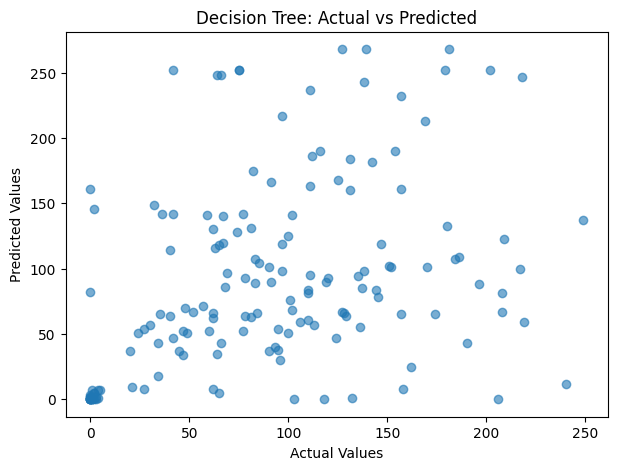

In [178]:
cm2 = confusion_matrix(y_test, y_pred2)

plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred2, alpha=0.6)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Decision Tree: Actual vs Predicted")
plt.show()

**Summary**

This scatter plot shows that the Decision Tree model predictions are reasonably close to the actual values, indicating acceptable performance.

# Comparison Both Models which is best for this data set

**Accuracy Comparison**

In [179]:
print("\nAccuracy Comparison:")
print("Random Forest Accuracy:", acc1)
print("Decision Tree Accuracy:", acc2)

if acc1 > acc2:
    print("Random Forest is better for this dataset.")
else:
    print("Decision Tree is better for this dataset.")


Accuracy Comparison:
Random Forest Accuracy: 0.056962025316455694
Decision Tree Accuracy: 0.05063291139240506
Random Forest is better for this dataset.


**Visualization Comparison**

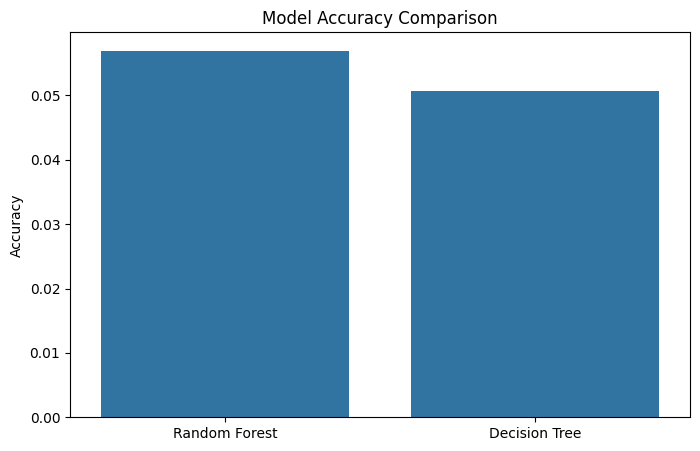

In [180]:
models = ['Random Forest', 'Decision Tree']
accuracies = [acc1, acc2]

plt.figure(figsize=(8,5))
sns.barplot(x=models, y=accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

**Summary**

Random Forest achieved slightly higher accuracy than Decision Tree, making it the better-performing model overall.

# 4th HR Attrition Prediction 


**Import Libraries**

In [181]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from scipy.stats import mode

**Load Dataset**

In [182]:
df = pd.read_csv("/kaggle/input/datasets/organizations/tevecsystems/retail-sales-forecasting/mock_kaggle.csv")

**5 Rows**

In [183]:
df.head()

,data,venda,estoque,preco
0,2014-01-01,0,4972,1.29
1,2014-01-02,70,4902,1.29
2,2014-01-03,59,4843,1.29
3,2014-01-04,93,4750,1.29
4,2014-01-05,96,4654,1.29


**Shape of Dataset**

In [184]:
print("Shape of dataset:", df.shape)

Shape of dataset: (937, 4)


**Understand Dataset**

In [185]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 937 entries, 0 to 936
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     937 non-null    object 
 1   venda    937 non-null    int64  
 2   estoque  937 non-null    int64  
 3   preco    937 non-null    float64
dtypes: float64(1), int64(2), object(1)
memory usage: 29.4+ KB


In [186]:
df.describe()

,venda,estoque,preco
count,937.000000,937.000000,937.000000
mean,90.533618,1608.258271,1.592572
std,80.682089,1356.691877,0.529502
min,0.000000,0.000000,0.000000
25%,33.000000,794.000000,1.290000
50%,76.000000,1348.000000,1.390000
75%,127.000000,1964.000000,1.890000
max,542.000000,7228.000000,2.980000


In [187]:
df.isnull().sum()

data       0
venda      0
estoque    0
preco      0
dtype: int64

**Data Cleaning**

In [188]:
df.columns = df.columns.str.strip()

**Drop  Columns**

In [189]:
drop_cols = [col for col in ['Row ID', 'Order ID', 'Customer ID', 'Postal Code'] if col in df.columns]
df.drop(columns=drop_cols, inplace=True)

**Duplicate Values**

In [190]:
print("Duplicates Before:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicates After:", df.duplicated().sum())

Duplicates Before: 0
Duplicates After: 0


**Handle Missing Values**

In [191]:
print(df.isnull().sum())
df.dropna(inplace=True)

data       0
venda      0
estoque    0
preco      0
dtype: int64


**Outlier Detection**

Columns in dataset:
['data', 'venda', 'estoque', 'preco']
Numeric columns: Index(['venda', 'estoque', 'preco'], dtype='object')


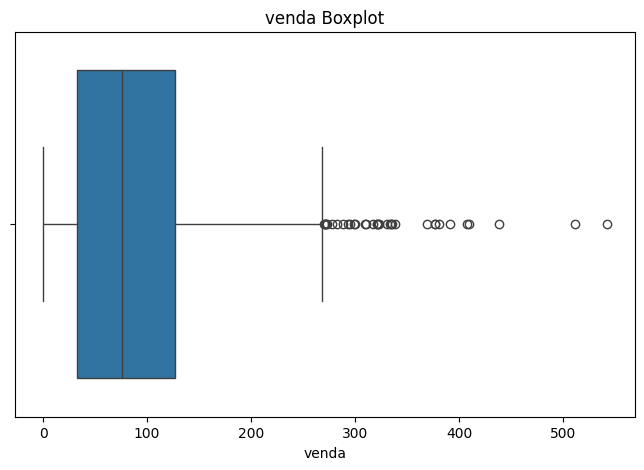

In [192]:
print("Columns in dataset:")
print(df.columns.tolist())

df.columns = df.columns.str.strip()

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numeric columns:", numeric_cols)

plt.figure(figsize=(8,5))
sns.boxplot(x=df[numeric_cols[0]])
plt.title(f"{numeric_cols[0]} Boxplot")
plt.show()

**Summary**

This code displays dataset columns, selects numeric features, and visualizes the distribution of the first numeric column using a boxplot to detect outliers.

**Remove Outliers**

In [193]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= (Q1 - 1.5 * IQR)) & (df[col] <= (Q3 + 1.5 * IQR))]

print("Shape After Outlier Removal:", df.shape)

Shape After Outlier Removal: (788, 4)


**Data Visualization**

Sales Distribution Replacement

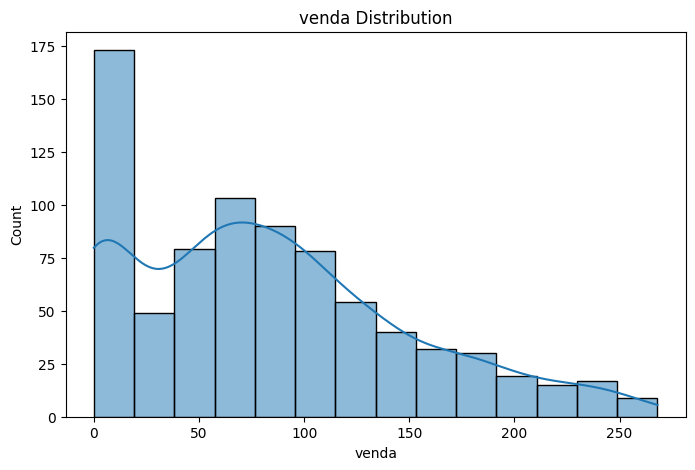

In [194]:
plt.figure(figsize=(8,5))
sns.histplot(df[numeric_cols[0]], kde=True)
plt.title(f"{numeric_cols[0]} Distribution")
plt.show()


**Summary**

This plot shows the distribution of an important numerical feature.
It helps understand spread and skewness.

**Category vs Sales Replacement**

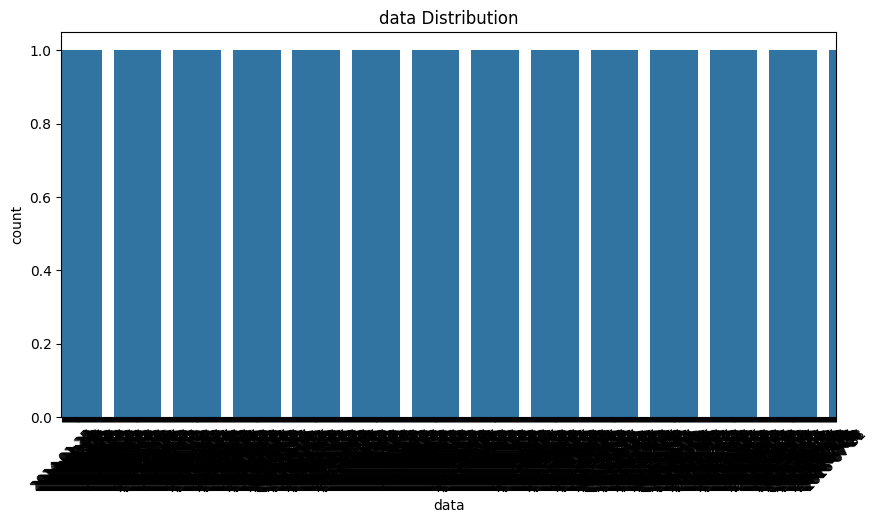

In [195]:
cat_cols = df.select_dtypes(include='object').columns

if len(cat_cols) > 0:
    plt.figure(figsize=(10,5))
    sns.countplot(x=df[cat_cols[0]])
    plt.title(f"{cat_cols[0]} Distribution")
    plt.xticks(rotation=45)
    plt.show()


**Summary**

Category distribution shows frequency of major classes.
It helps identify dominant groups.

**Correlation Heatmap**

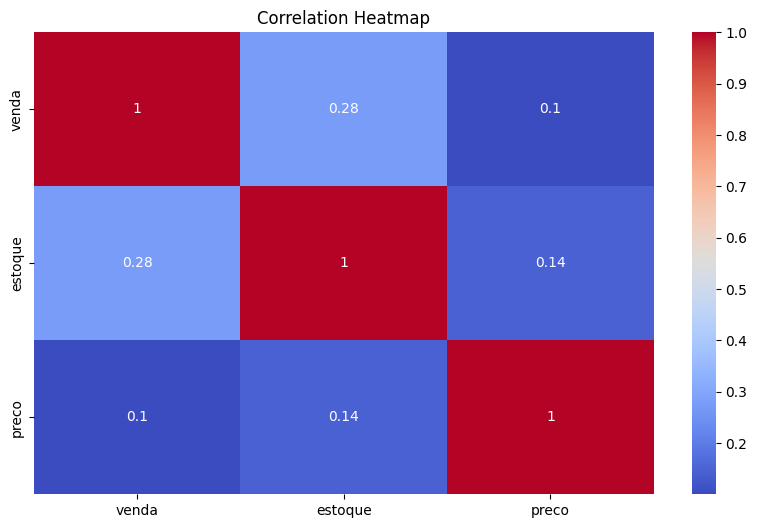

In [196]:
plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


**Summary**

Heatmap shows relationships among numerical variables.
Strong correlations may influence clustering.

**Encode Categorical Data**

In [197]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

**Split Features and Target**

In [198]:
target = df.columns[0]

X = df.drop(columns=[target])
y = df[target]

**Train-Test Split**

In [199]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Scaling**

In [200]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Best Clusters**

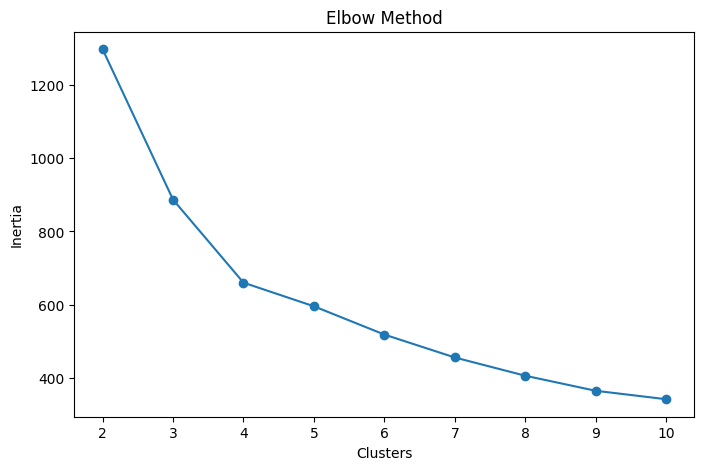

In [201]:
inertia = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_train_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.show()



**Summary**

Elbow method helps choose the best number of clusters.
The bend point suggests optimal K value.

In [202]:
best_k = 3

# 4th HR Attrition Prediction 

****I USE UNSUPERVISED LEARNING ( K Means ) ON 1ST MODEL****

**1st Train Model**

In [203]:
model1 = KMeans(n_clusters=best_k, random_state=42)
y_pred1 = model1.fit_predict(X_test_scaled)


**Map clusters to labels**

In [204]:
labels1 = np.zeros_like(y_pred1)
for i in range(best_k):
    mask = (y_pred1 == i)
    labels1[mask] = mode(y_test[mask], keepdims=True)[0]


**1st Prediction**

In [205]:
y_pred1 = model1.fit_predict(X_test_scaled)

**1st Accuracy**

In [206]:
acc1 = accuracy_score(y_test, labels1)

print("1st Model Accuracy:", acc1)

1st Model Accuracy: 0.0189873417721519


**1st Confusion Matrix**

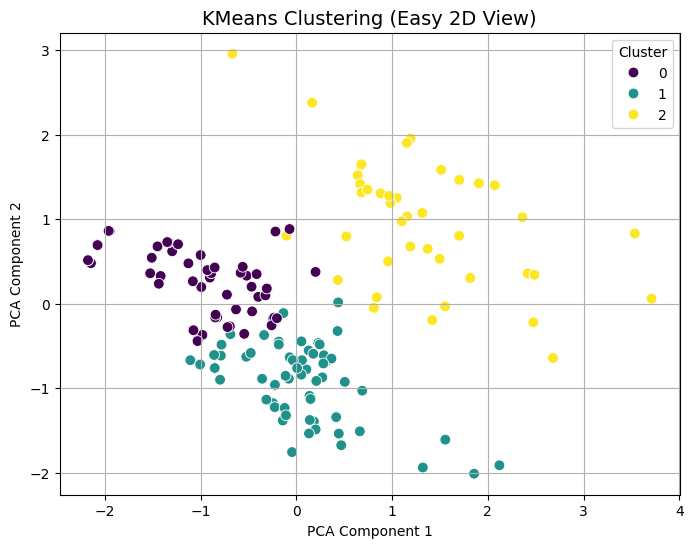

In [208]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test_scaled)
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=y_pred1,   # clusters
    palette='viridis',
    s=60
)

plt.title("KMeans Clustering (Easy 2D View)", fontsize=14)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()

**Summary**

This plot shows the clustering results after reducing the data to 2 dimensions using PCA, making it easy to visualize group formation.
Each color represents a different cluster, helping to clearly see how data points are grouped together.

# 4th HR Attrition Prediction 
****I USE UNSUPERVISED LEARNING (DBSCAN) ON 2ND MODEL****

**2nd Train Model**

In [209]:
from sklearn.cluster import DBSCAN

model2 = DBSCAN(eps=0.5, min_samples=5)
y_pred2 = model2.fit_predict(X_test_scaled)

**DBSCAN noise handle (labels)**

In [210]:
labels2 = np.zeros_like(y_pred2)

unique_clusters = set(y_pred2)

for cluster in unique_clusters:
    if cluster == -1:
        continue  # noise ignore
    mask = (y_pred2 == cluster)
    labels2[mask] = mode(y_test[mask], keepdims=True).mode[0]

**2nd Accuracy**

In [211]:
acc2 = accuracy_score(y_test, labels2)
print("2nd Model (DBSCAN) Accuracy:", acc2)

2nd Model (DBSCAN) Accuracy: 0.02531645569620253


**2nd Confusion Matrix**

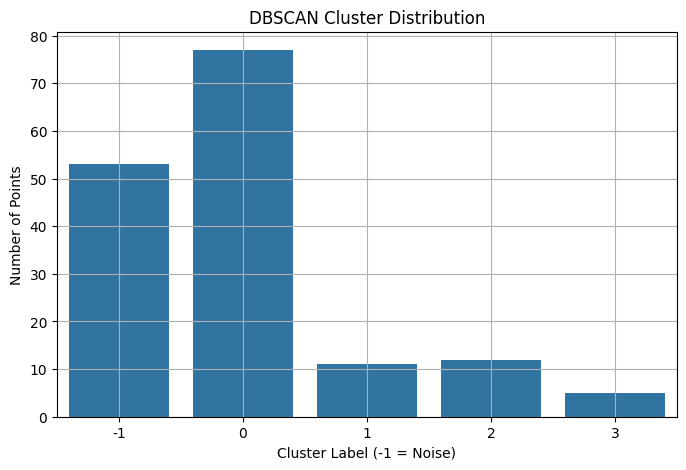

In [212]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

unique, counts = np.unique(y_pred2, return_counts=True)

plt.figure(figsize=(8,5))

sns.barplot(x=unique, y=counts)

plt.title("DBSCAN Cluster Distribution")
plt.xlabel("Cluster Label (-1 = Noise)")
plt.ylabel("Number of Points")
plt.grid(True)
plt.show()

**Summary**

This plot shows the distribution of data points across DBSCAN clusters, including noise points labeled as -1.

# Comparison Both Models which is best for this data set

**Accuracy Comparison**

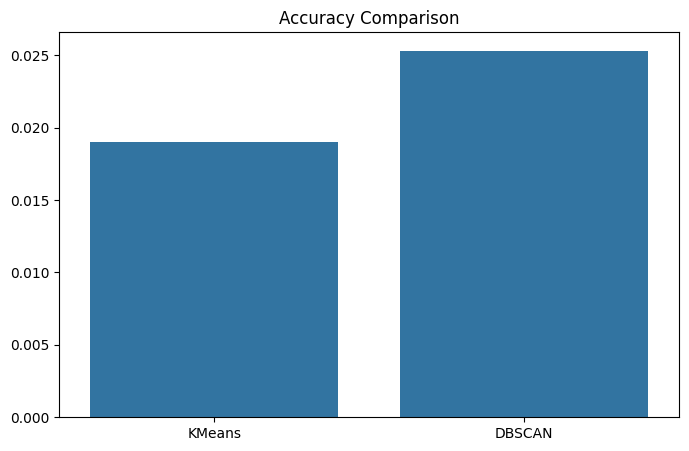

In [213]:
models = ['KMeans', 'DBSCAN']
accuracies = [acc1, acc2]

plt.figure(figsize=(8,5))
sns.barplot(x=models, y=accuracies)
plt.title("Accuracy Comparison")
plt.show()

**Summary**

This bar chart compares the accuracies of KMeans and DBSCAN models to show which clustering method performs better on the dataset.

# THE END